# Classification Landscape

This notebook maps out the distribution of Collatz classes across the integers.
We visualize how numbers distribute across dropping sets, stopping classes,
and orbital oddity values, reproducing and extending the patterns described in
Papers 1 and 2.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collatz.core import total_stopping_time
from collatz.dropping import (
    dropping_set, orbital_oddity, classify_range as dropping_classify_range,
)
from collatz.stopping import (
    stopping_point, stopping_class, stopping_line_slope,
    classify_range as stopping_classify_range,
)

%matplotlib inline
plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 11})
print("Imports ready.")

Imports ready.


## Dropping Set Distribution

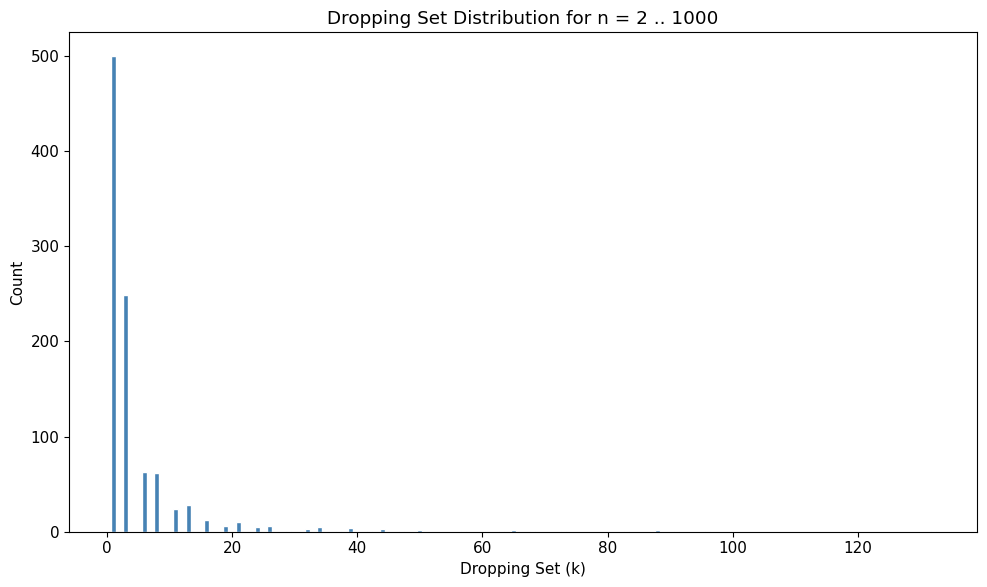

Distinct dropping sets found: 31
  Set   1:  500 members
  Set   3:  249 members
  Set   6:   63 members
  Set   8:   62 members
  Set  11:   24 members
  Set  13:   28 members
  Set  16:   12 members
  Set  19:    6 members
  Set  21:   10 members
  Set  24:    5 members


In [2]:
# Classify n = 2..1000 by dropping set and plot a histogram
N_MAX = 1000
ds_values = [dropping_set(n) for n in range(2, N_MAX + 1)]

fig, ax = plt.subplots()
unique_ds = sorted(set(ds_values))
counts = [ds_values.count(d) for d in unique_ds]
ax.bar(unique_ds, counts, color="steelblue", edgecolor="white")
ax.set_xlabel("Dropping Set (k)")
ax.set_ylabel("Count")
ax.set_title(f"Dropping Set Distribution for n = 2 .. {N_MAX}")
plt.tight_layout()
plt.show()

print(f"Distinct dropping sets found: {len(unique_ds)}")
for d, c in zip(unique_ds[:10], counts[:10]):
    print(f"  Set {d:>3}: {c:>4} members")

## Stopping Time Distribution

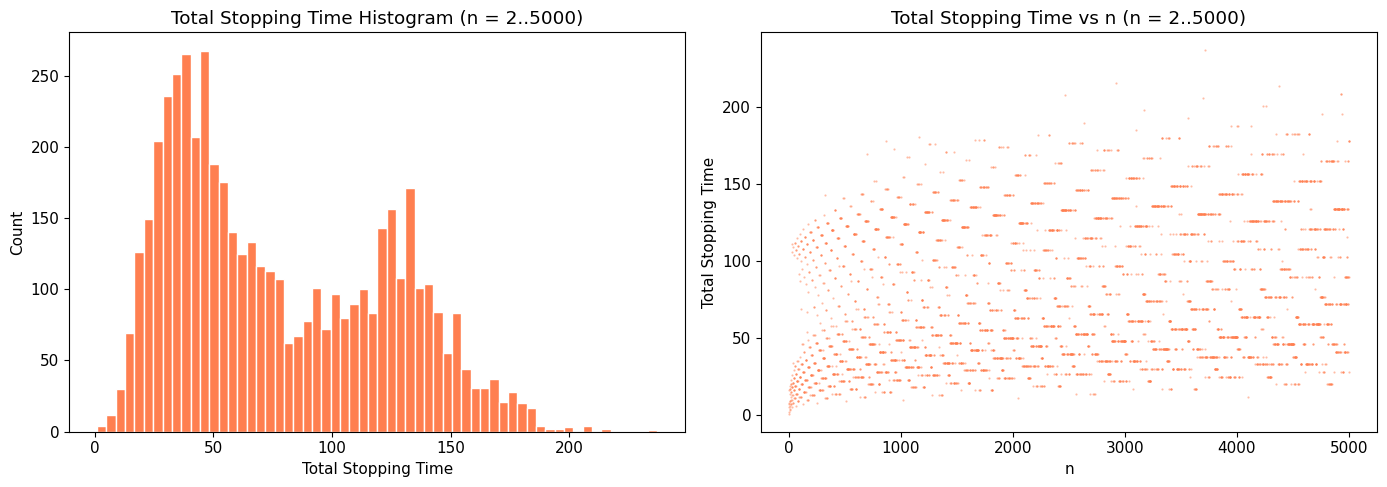

Max stopping time: 237 at n = 3711
Mean stopping time: 77.6


In [3]:
# Plot stopping time (total) distribution for n = 2..5000
N_STOP = 5000
stop_times = [total_stopping_time(n) for n in range(2, N_STOP + 1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(stop_times, bins=60, color="coral", edgecolor="white")
axes[0].set_xlabel("Total Stopping Time")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Total Stopping Time Histogram (n = 2..{N_STOP})")

# Scatter: n vs stopping time
axes[1].scatter(range(2, N_STOP + 1), stop_times, s=0.3, alpha=0.5, color="coral")
axes[1].set_xlabel("n")
axes[1].set_ylabel("Total Stopping Time")
axes[1].set_title(f"Total Stopping Time vs n (n = 2..{N_STOP})")

plt.tight_layout()
plt.show()

print(f"Max stopping time: {max(stop_times)} at n = {stop_times.index(max(stop_times)) + 2}")
print(f"Mean stopping time: {np.mean(stop_times):.1f}")

## Orbital Oddity vs Dropping Set

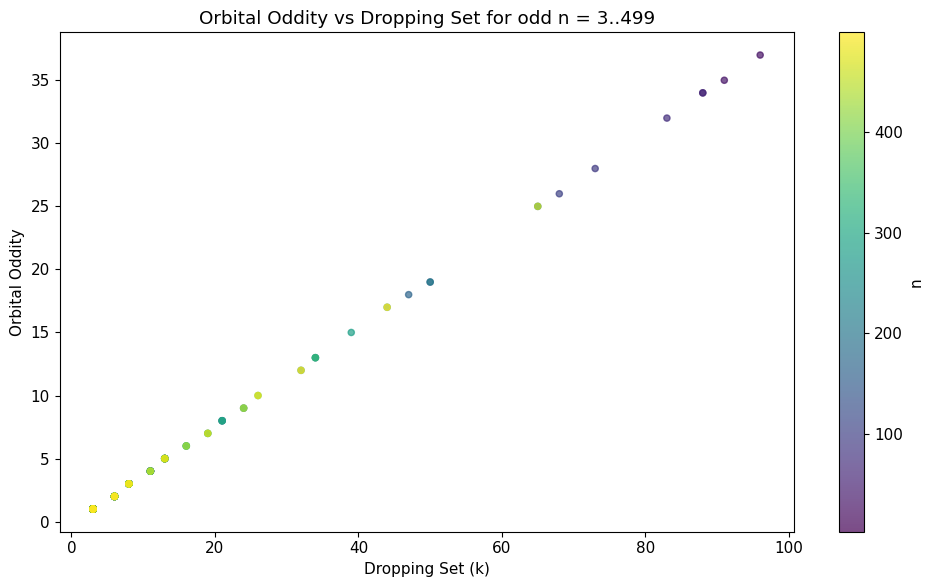

Dropping Set -> Orbital Oddity (unique values per set):
  Set   3: oddity = {1}
  Set   6: oddity = {2}
  Set   8: oddity = {3}
  Set  11: oddity = {4}
  Set  13: oddity = {5}
  Set  16: oddity = {6}
  Set  19: oddity = {7}
  Set  21: oddity = {8}
  Set  24: oddity = {9}
  Set  26: oddity = {10}
  Set  32: oddity = {12}
  Set  34: oddity = {13}


In [4]:
# Scatter plot of dropping_set vs orbital_oddity for odd n up to 500
odd_ns = [n for n in range(3, 501, 2)]
ds_vals = [dropping_set(n) for n in odd_ns]
oo_vals = [orbital_oddity(n) for n in odd_ns]

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(ds_vals, oo_vals, c=odd_ns, cmap="viridis", s=20, alpha=0.7)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("n")
ax.set_xlabel("Dropping Set (k)")
ax.set_ylabel("Orbital Oddity")
ax.set_title("Orbital Oddity vs Dropping Set for odd n = 3..499")
plt.tight_layout()
plt.show()

# Show relationship is deterministic (same set -> same oddity)
ds_oo_map = {}
for d, o in zip(ds_vals, oo_vals):
    ds_oo_map.setdefault(d, set()).add(o)
print("Dropping Set -> Orbital Oddity (unique values per set):")
for d in sorted(ds_oo_map)[:12]:
    print(f"  Set {d:>3}: oddity = {ds_oo_map[d]}")

## Stopping Points Visualization

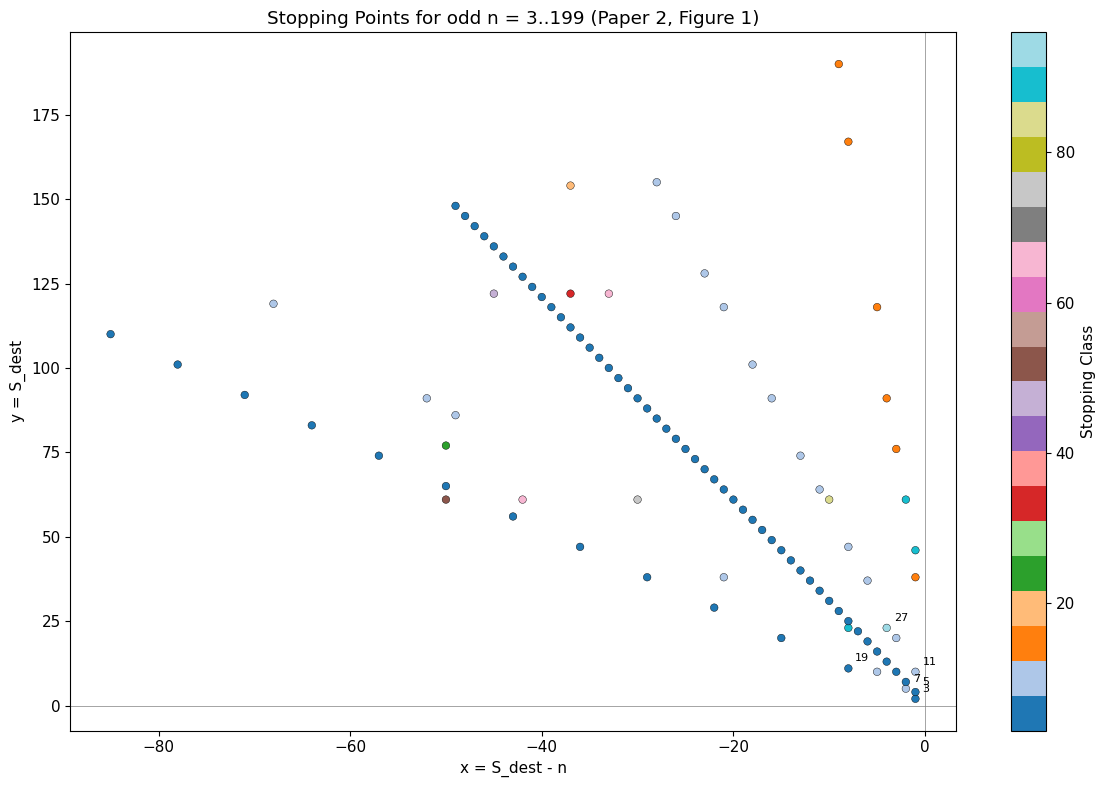

In [5]:
# Plot stopping points for odd numbers 3..200, colored by stopping class
# Reproduces the pattern from Paper 2, Figure 1
odd_range = list(range(3, 201, 2))
points = [stopping_point(n) for n in odd_range]
classes = [stopping_class(n) for n in odd_range]

xs = [p[0] for p in points]
ys = [p[1] for p in points]

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(xs, ys, c=classes, cmap="tab20", s=30, edgecolors="black", linewidth=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Stopping Class")

# Annotate a few points
for n in [3, 5, 7, 11, 19, 27]:
    sp = stopping_point(n)
    ax.annotate(str(n), sp, textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel("x = S_dest - n")
ax.set_ylabel("y = S_dest")
ax.set_title("Stopping Points for odd n = 3..199 (Paper 2, Figure 1)")
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
plt.tight_layout()
plt.show()

## Stopping Class Lines

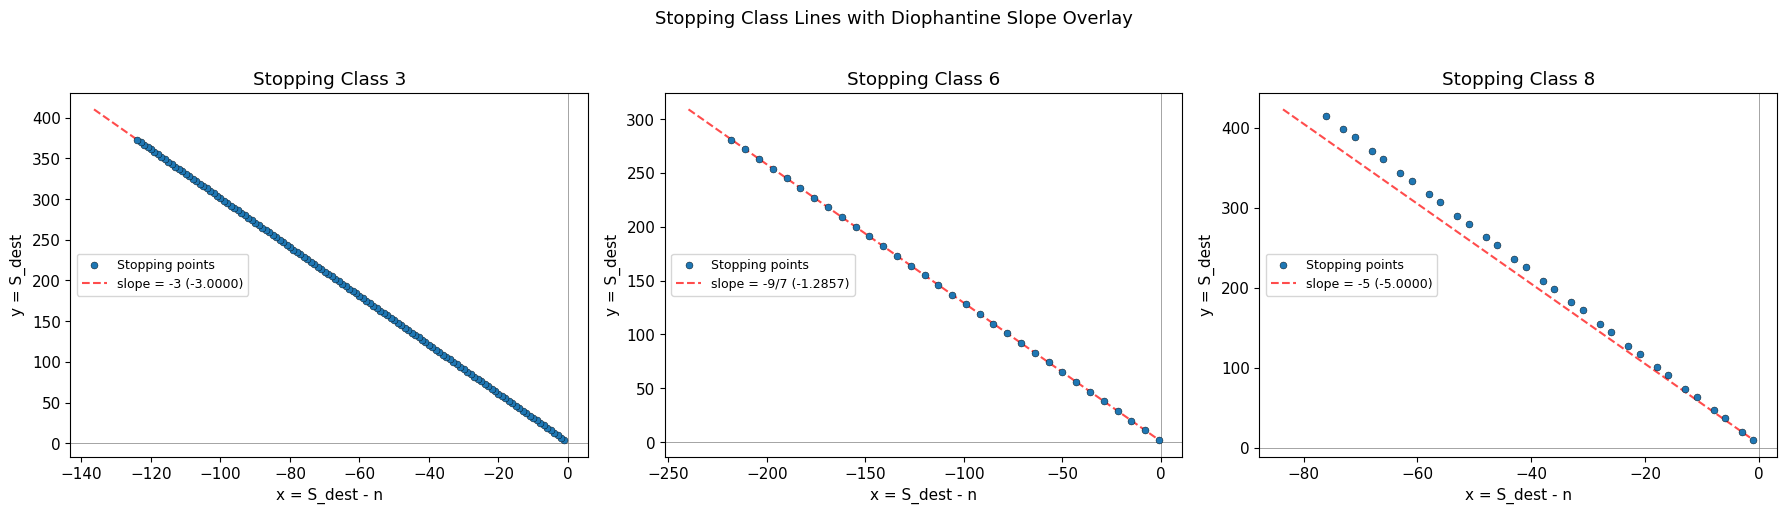

Slopes:
  Class 3: slope = -3 = -3.000000
  Class 6: slope = -9/7 = -1.285714
  Class 8: slope = -5 = -5.000000


In [6]:
# For classes 3, 6, 8: plot stopping points and overlay Diophantine line equations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, k in enumerate([3, 6, 8]):
    ax = axes[idx]
    # Collect members of this class from odd numbers
    members = [n for n in range(3, 501, 2) if stopping_class(n) == k]
    pts = [stopping_point(n) for n in members]
    mx = [p[0] for p in pts]
    my = [p[1] for p in pts]

    ax.scatter(mx, my, s=25, zorder=3, edgecolors="black", linewidth=0.3, label="Stopping points")

    # Overlay the Diophantine line
    slope = stopping_line_slope(k)
    if mx:
        x_line = np.linspace(min(mx) * 1.1, max(mx) * 1.1, 200)
        # Use the first point as anchor
        x0, y0 = pts[0]
        y_line = float(slope) * (x_line - x0) + y0
        ax.plot(x_line, y_line, "r--", lw=1.5, alpha=0.7, label=f"slope = {slope} ({float(slope):.4f})")

    ax.set_xlabel("x = S_dest - n")
    ax.set_ylabel("y = S_dest")
    ax.set_title(f"Stopping Class {k}")
    ax.legend(fontsize=9)
    ax.axhline(0, color="grey", lw=0.5)
    ax.axvline(0, color="grey", lw=0.5)

plt.suptitle("Stopping Class Lines with Diophantine Slope Overlay", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Slopes:")
for k in [3, 6, 8]:
    s = stopping_line_slope(k)
    print(f"  Class {k}: slope = {s} = {float(s):.6f}")

## Heatmap: Stopping Time by n

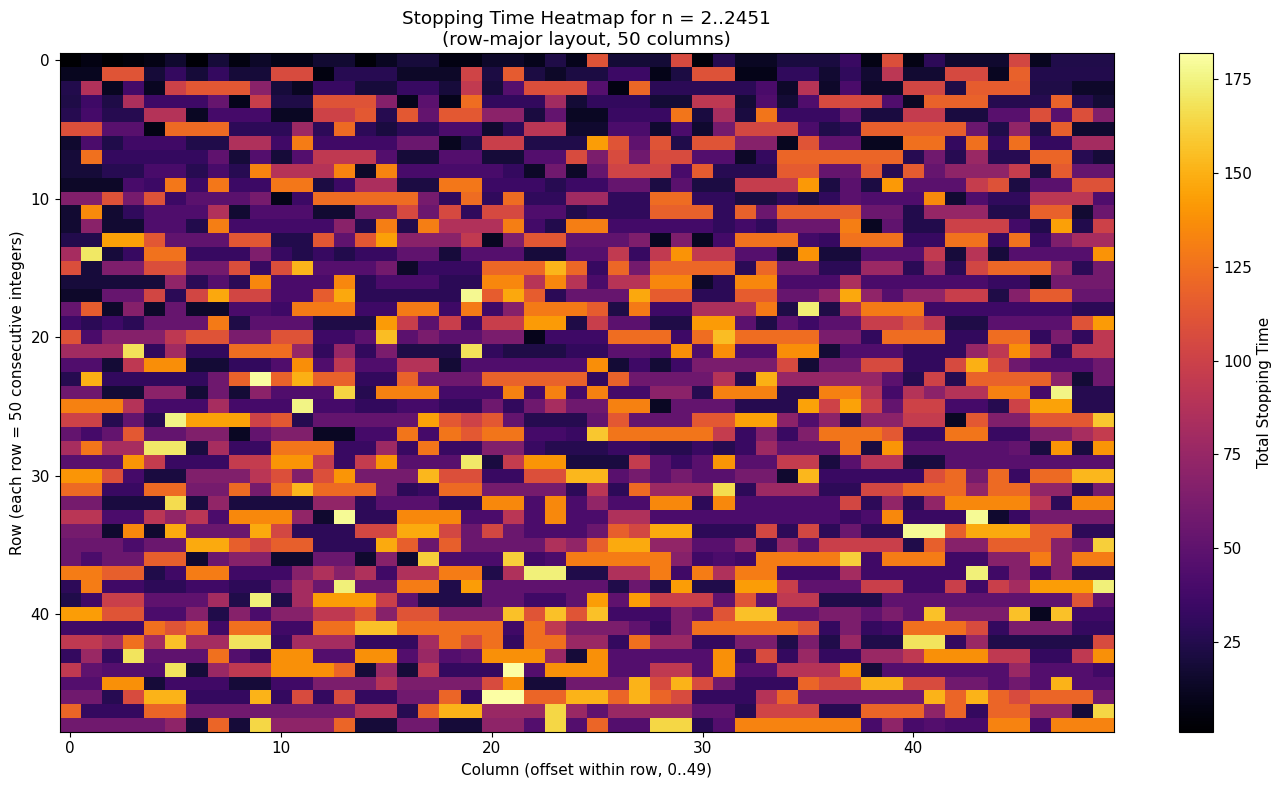

Grid shape: (49, 50)
Min stopping time: 1, Max: 182


In [7]:
# Create a 2D heatmap of stopping times
# Arrange integers 2..N in a 2D grid and color each cell by total stopping time
N_HEAT = 2500
cols = 50
rows = (N_HEAT - 1) // cols  # exclude n=1
total = rows * cols

st_vals = [total_stopping_time(n) for n in range(2, 2 + total)]
grid = np.array(st_vals).reshape(rows, cols)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(grid, aspect="auto", cmap="inferno", interpolation="nearest")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Total Stopping Time")
ax.set_xlabel(f"Column (offset within row, 0..{cols - 1})")
ax.set_ylabel(f"Row (each row = {cols} consecutive integers)")
ax.set_title(f"Stopping Time Heatmap for n = 2..{1 + total}\n(row-major layout, {cols} columns)")
plt.tight_layout()
plt.show()

print(f"Grid shape: {grid.shape}")
print(f"Min stopping time: {grid.min()}, Max: {grid.max()}")